# Illegal Mining Detection — Transfer Learning Models
**Project:** Detection of Illegal Mining Using Satellite Imagery and CNN  
**Notebook:** `train_transfer_models.ipynb`  
**Stage:** 2b — ResNet-18 & MobileNetV2 Transfer Learning

Pipeline:
1. `extract_patches.ipynb` ✅ Done
2. `train_cnn_model.ipynb` ✅ Done (Custom CNN — 91–92% accuracy)
3. `train_transfer_models.ipynb` ← **You are here**
4. `temporal_analysis.ipynb` → Next

This notebook trains two pretrained models and compares all three against the Custom CNN.


## Cell 1 — Import Libraries

In [1]:
import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

# ── Device ────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
if torch.cuda.is_available():
    print('GPU :', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1), 'GB')


Using device: cuda
GPU : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.0 GB


## Cell 2 — Config & Paths

In [2]:
# ── SAME dataset path as train_cnn_model.ipynb ───────────────────────────
DATASET_PATH = r"R:\ai project image\cnn dataset"

# Hyperparameters
IMAGE_SIZE_TRANSFER = 224     # ResNet & MobileNet require 224x224
BATCH_SIZE          = 32
EPOCHS_HEAD         = 10      # Phase 1: head-only warmup
EPOCHS_FINETUNE     = 40      # Phase 2: full fine-tune
LR_HEAD             = 1e-3    # Higher LR for warmup
LR_FINETUNE         = 1e-4    # Lower LR for fine-tuning
PATIENCE            = 10
RANDOM_SEED         = 42
NUM_CLASSES         = 2

SAVE_DIR = 'saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs('plots', exist_ok=True)

torch.manual_seed(RANDOM_SEED)

print('Dataset     :', DATASET_PATH)
print('Image size  :', IMAGE_SIZE_TRANSFER)
print('Batch size  :', BATCH_SIZE)
print('Save dir    :', SAVE_DIR)


Dataset     : R:\ai project image\cnn dataset
Image size  : 224
Batch size  : 32
Save dir    : saved_models


## Cell 3 — Transforms for Pretrained Models

> **Note:** ResNet-18 and MobileNetV2 were pretrained on ImageNet at 224×224. We resize our 64×64 patches to 224×224 and use ImageNet normalisation stats.

In [3]:
# Training transform — with augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE_TRANSFER, IMAGE_SIZE_TRANSFER)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet stats
                         std= [0.229, 0.224, 0.225])
])

# Val / Test transform — no augmentation
val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE_TRANSFER, IMAGE_SIZE_TRANSFER)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225])
])

print('Train transform :', train_transform)
print('Val/Test transform:', val_test_transform)


Train transform : Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.9, 1.1), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Val/Test transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## Cell 4 — Load & Split Dataset

In [4]:
# Load full dataset with val/test transform first
full_dataset = datasets.ImageFolder(root=DATASET_PATH,
                                    transform=val_test_transform)

print('Classes      :', full_dataset.classes)
print('Class indices:', full_dataset.class_to_idx)
print('Total images :', len(full_dataset))

# Split 70 / 15 / 15
total_size = len(full_dataset)
train_size = int(0.70 * total_size)
val_size   = int(0.15 * total_size)
test_size  = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(RANDOM_SEED)
)

# Apply augmentation to training set only
train_dataset.dataset.transform = train_transform

print(f'Train : {len(train_dataset)} samples')
print(f'Val   : {len(val_dataset)} samples')
print(f'Test  : {len(test_dataset)} samples')

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)

print('DataLoaders ready!')


Classes      : ['mining', 'non mining']
Class indices: {'mining': 0, 'non mining': 1}
Total images : 2955
Train : 2068 samples
Val   : 443 samples
Test  : 444 samples
DataLoaders ready!


## Cell 5 — Shared Training & Evaluation Functions

In [5]:
def train_model(model, model_name, train_loader, val_loader,
                num_epochs, lr, patience=PATIENCE):
    """Universal training loop with early stopping and checkpointing."""

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = ReduceLROnPlateau(optimizer, mode='max',
                                  factor=0.5, patience=5, verbose=True)

    best_val_acc  = 0.0
    best_weights  = copy.deepcopy(model.state_dict())
    no_improve    = 0
    save_path     = os.path.join(SAVE_DIR, f'{model_name}.pth')

    history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  []}

    print(f'\n{"="*60}')
    print(f'  Training: {model_name}  |  epochs={num_epochs}  lr={lr}')
    print(f'{"="*60}')

    for epoch in range(num_epochs):
        t0 = time.time()

        # ── Train ────────────────────────────────────────────────────────
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            t_loss    += loss.item() * imgs.size(0)
            _, preds   = torch.max(out, 1)
            t_correct += (preds == labels).sum().item()
            t_total   += labels.size(0)

        # ── Val ──────────────────────────────────────────────────────────
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out  = model(imgs)
                loss = criterion(out, labels)
                v_loss    += loss.item() * imgs.size(0)
                _, preds   = torch.max(out, 1)
                v_correct += (preds == labels).sum().item()
                v_total   += labels.size(0)

        train_loss = t_loss / t_total
        val_loss   = v_loss / v_total
        train_acc  = t_correct / t_total
        val_acc    = v_correct / v_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        scheduler.step(val_acc)
        elapsed = time.time() - t0

        print(f'Epoch [{epoch+1:02d}/{num_epochs}]  '
              f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f}  |  '
              f'Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}  |  '
              f'{elapsed:.1f}s')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            no_improve   = 0
            torch.save(best_weights, save_path)
            print(f'  >> Saved best model  (val_acc = {best_val_acc:.4f})')
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stopping at epoch {epoch+1}')
                break

    model.load_state_dict(best_weights)
    print(f'\nBest Val Accuracy: {best_val_acc:.4f}  ->  {save_path}')
    return model, history, best_val_acc


def evaluate_model(model, model_name, test_loader):
    """Full test-set evaluation: accuracy, AUC, report, confusion matrix."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs    = imgs.to(device)
            out     = model(imgs)
            probs   = torch.softmax(out, dim=1)[:, 1]
            _, preds = torch.max(out, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    acc    = (all_preds == all_labels).mean()
    auc    = roc_auc_score(all_labels, all_probs)
    report = classification_report(all_labels, all_preds,
                                   target_names=['Non-Mining', 'Mining'])
    cm     = confusion_matrix(all_labels, all_preds)

    print(f'\n{"="*60}')
    print(f'  Test Results — {model_name}')
    print(f'{"="*60}')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  AUC-ROC  : {auc:.4f}')
    print(f'\n{report}')
    print(f'Confusion Matrix:\n{cm}')

    return {'name': model_name, 'accuracy': acc, 'auc': auc,
            'report': report, 'cm': cm,
            'preds': all_preds, 'labels': all_labels, 'probs': all_probs}


def plot_history(history, model_name):
    """Plot and save training curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(history['train_acc'],  label='Train Acc',  color='steelblue')
    ax1.plot(history['val_acc'],    label='Val Acc',    color='darkorange')
    ax1.set_title(f'{model_name} — Accuracy')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(True)

    ax2.plot(history['train_loss'], label='Train Loss', color='steelblue')
    ax2.plot(history['val_loss'],   label='Val Loss',   color='darkorange')
    ax2.set_title(f'{model_name} — Loss')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(True)

    plt.suptitle(f'{model_name} — Training History', fontsize=13)
    plt.tight_layout()
    fname = f'plots/{model_name.lower().replace("-","_")}_training.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')


def plot_confusion(result):
    """Plot confusion matrix for a result dict."""
    plt.figure(figsize=(5, 4))
    sns.heatmap(result['cm'], annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Mining','Mining'],
                yticklabels=['Non-Mining','Mining'])
    plt.title(f'Confusion Matrix — {result["name"]}')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout()
    fname = f'plots/{result["name"].lower().replace("-","_")}_cm.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

print('All functions defined.')


All functions defined.


## Cell 6 — Build ResNet-18

**Strategy:**
- Load ImageNet pretrained weights
- Freeze all layers
- Replace the final FC layer with a custom 2-class head
- Phase 1 (10 epochs): train head only at lr=1e-3
- Phase 2 (40 epochs): unfreeze all, fine-tune at lr=1e-4


In [6]:
def build_resnet18():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Freeze all pretrained layers
    for param in model.parameters():
        param.requires_grad = False

    # Replace classifier head (original: Linear(512, 1000))
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, NUM_CLASSES)       # 2-class output
    )
    return model.to(device)

resnet18 = build_resnet18()

trainable = sum(p.numel() for p in resnet18.parameters() if p.requires_grad)
total     = sum(p.numel() for p in resnet18.parameters())
print(f'ResNet-18')
print(f'  Trainable params : {trainable:,}  (head only)')
print(f'  Total params     : {total:,}')
print(f'  Frozen params    : {total - trainable:,}')


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Rohit Bansal/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100.0%


ResNet-18
  Trainable params : 131,842  (head only)
  Total params     : 11,308,354
  Frozen params    : 11,176,512


## Cell 7 — ResNet-18 Phase 1: Head Warmup (10 epochs)

In [7]:
print('ResNet-18 — Phase 1: Training head only...')

resnet18, history_r_p1, _ = train_model(
    resnet18,
    model_name   = 'resnet18_phase1',
    train_loader = train_loader,
    val_loader   = val_loader,
    num_epochs   = EPOCHS_HEAD,
    lr           = LR_HEAD,
    patience     = EPOCHS_HEAD        # no early stopping in warmup
)

print('Phase 1 complete.')


ResNet-18 — Phase 1: Training head only...

  Training: resnet18_phase1  |  epochs=10  lr=0.001


c:\Users\Rohit Bansal\anaconda3\envs\mining_env\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [01/10]  Train Loss: 0.5424  Acc: 0.7515  |  Val Loss: 0.3684  Acc: 0.8600  |  12.8s
  >> Saved best model  (val_acc = 0.8600)
Epoch [02/10]  Train Loss: 0.4415  Acc: 0.8085  |  Val Loss: 0.3569  Acc: 0.8307  |  13.2s
Epoch [03/10]  Train Loss: 0.4179  Acc: 0.8254  |  Val Loss: 0.3540  Acc: 0.8442  |  13.4s
Epoch [04/10]  Train Loss: 0.4462  Acc: 0.7955  |  Val Loss: 0.3508  Acc: 0.8533  |  12.5s
Epoch [05/10]  Train Loss: 0.4174  Acc: 0.8104  |  Val Loss: 0.3172  Acc: 0.8555  |  12.5s
Epoch [06/10]  Train Loss: 0.4243  Acc: 0.8162  |  Val Loss: 0.3370  Acc: 0.8510  |  12.5s
Epoch [07/10]  Train Loss: 0.3799  Acc: 0.8395  |  Val Loss: 0.3088  Acc: 0.8713  |  13.6s
  >> Saved best model  (val_acc = 0.8713)
Epoch [08/10]  Train Loss: 0.4243  Acc: 0.8206  |  Val Loss: 0.3350  Acc: 0.8691  |  13.0s
Epoch [09/10]  Train Loss: 0.3891  Acc: 0.8240  |  Val Loss: 0.3099  Acc: 0.8555  |  12.4s
Epoch [10/10]  Train Loss: 0.3796  Acc: 0.8477  |  Val Loss: 0.3070  Acc: 0.8826  |  12.7s
  >> S

## Cell 8 — ResNet-18 Phase 2: Full Fine-Tuning

In [8]:
# Unfreeze ALL layers for end-to-end fine-tuning
for param in resnet18.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in resnet18.parameters() if p.requires_grad)
print(f'All layers unfrozen — trainable params: {trainable:,}')
print('ResNet-18 — Phase 2: Full fine-tuning...')

resnet18, history_r, best_r = train_model(
    resnet18,
    model_name   = 'resnet18',
    train_loader = train_loader,
    val_loader   = val_loader,
    num_epochs   = EPOCHS_FINETUNE,
    lr           = LR_FINETUNE,
    patience     = PATIENCE
)


All layers unfrozen — trainable params: 11,308,354
ResNet-18 — Phase 2: Full fine-tuning...

  Training: resnet18  |  epochs=40  lr=0.0001
Epoch [01/40]  Train Loss: 0.3040  Acc: 0.8806  |  Val Loss: 0.1917  Acc: 0.9187  |  14.8s
  >> Saved best model  (val_acc = 0.9187)
Epoch [02/40]  Train Loss: 0.2221  Acc: 0.9168  |  Val Loss: 0.2067  Acc: 0.9187  |  13.6s
Epoch [03/40]  Train Loss: 0.2130  Acc: 0.9149  |  Val Loss: 0.1708  Acc: 0.9300  |  13.5s
  >> Saved best model  (val_acc = 0.9300)
Epoch [04/40]  Train Loss: 0.1995  Acc: 0.9241  |  Val Loss: 0.2105  Acc: 0.9165  |  13.5s
Epoch [05/40]  Train Loss: 0.1735  Acc: 0.9318  |  Val Loss: 0.1767  Acc: 0.9300  |  13.6s
Epoch [06/40]  Train Loss: 0.1742  Acc: 0.9318  |  Val Loss: 0.1934  Acc: 0.9300  |  17.9s
Epoch [07/40]  Train Loss: 0.1679  Acc: 0.9318  |  Val Loss: 0.1812  Acc: 0.9165  |  19.6s
Epoch [08/40]  Train Loss: 0.1692  Acc: 0.9323  |  Val Loss: 0.2472  Acc: 0.9007  |  19.5s
Epoch [09/40]  Train Loss: 0.1738  Acc: 0.9333  |

## Cell 9 — ResNet-18 Evaluation


  Test Results — ResNet-18
  Accuracy : 0.9189
  AUC-ROC  : 0.9738

              precision    recall  f1-score   support

  Non-Mining       0.90      0.88      0.89       165
      Mining       0.93      0.94      0.94       279

    accuracy                           0.92       444
   macro avg       0.91      0.91      0.91       444
weighted avg       0.92      0.92      0.92       444

Confusion Matrix:
[[146  19]
 [ 17 262]]


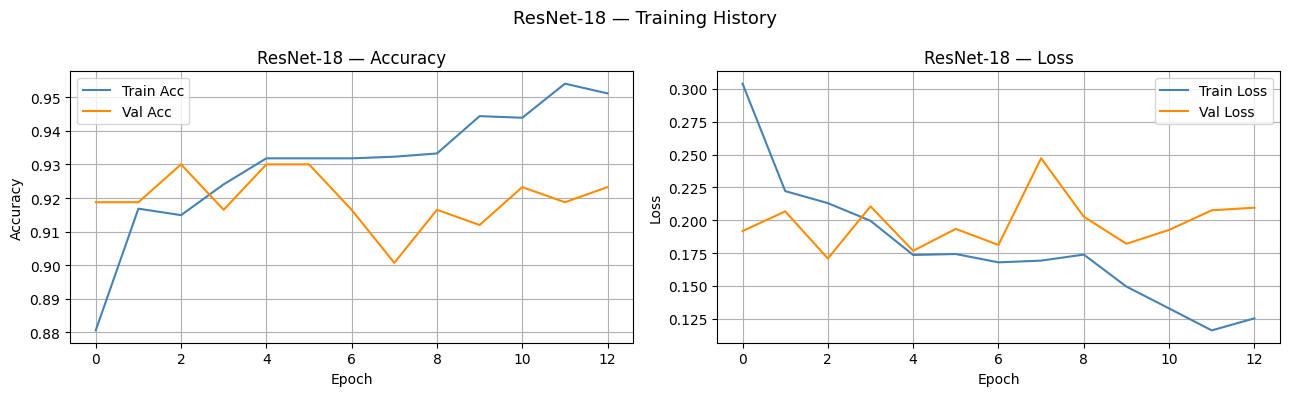

Saved: plots/resnet_18_training.png


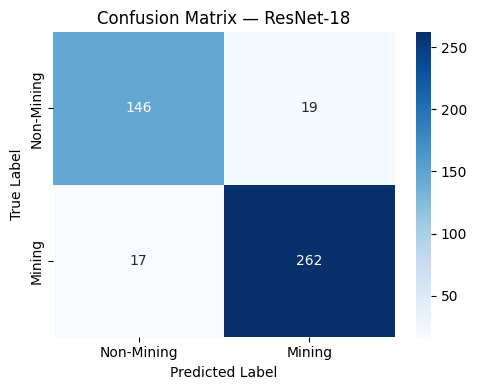

Saved: plots/resnet_18_cm.png


In [9]:
# Load best checkpoint
resnet18.load_state_dict(torch.load('saved_models/resnet18.pth',
                                     map_location=device))

# Evaluate
resnet18_results = evaluate_model(resnet18, 'ResNet-18', test_loader)

# Plots
plot_history(history_r, 'ResNet-18')
plot_confusion(resnet18_results)


## Cell 10 — Build MobileNetV2

**Strategy:** Same two-phase approach as ResNet-18.
MobileNetV2 classifier is `model.classifier[1]` with `in_features=1280`.


In [10]:
def build_mobilenetv2():
    model = models.mobilenet_v2(
        weights=models.MobileNet_V2_Weights.IMAGENET1K_V1
    )

    # Freeze all pretrained layers
    for param in model.parameters():
        param.requires_grad = False

    # Replace classifier (original: Linear(1280, 1000))
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1280, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, NUM_CLASSES)       # 2-class output
    )
    return model.to(device)

mobilenetv2 = build_mobilenetv2()

trainable = sum(p.numel() for p in mobilenetv2.parameters() if p.requires_grad)
total     = sum(p.numel() for p in mobilenetv2.parameters())
print(f'MobileNetV2')
print(f'  Trainable params : {trainable:,}  (head only)')
print(f'  Total params     : {total:,}')
print(f'  Frozen params    : {total - trainable:,}')


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\Rohit Bansal/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth
100.0%


MobileNetV2
  Trainable params : 328,450  (head only)
  Total params     : 2,552,322
  Frozen params    : 2,223,872


## Cell 11 — MobileNetV2 Phase 1: Head Warmup (10 epochs)

In [11]:
print('MobileNetV2 — Phase 1: Training head only...')

mobilenetv2, history_m_p1, _ = train_model(
    mobilenetv2,
    model_name   = 'mobilenetv2_phase1',
    train_loader = train_loader,
    val_loader   = val_loader,
    num_epochs   = EPOCHS_HEAD,
    lr           = LR_HEAD,
    patience     = EPOCHS_HEAD
)

print('Phase 1 complete.')


c:\Users\Rohit Bansal\anaconda3\envs\mining_env\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


MobileNetV2 — Phase 1: Training head only...

  Training: mobilenetv2_phase1  |  epochs=10  lr=0.001
Epoch [01/10]  Train Loss: 0.4654  Acc: 0.7945  |  Val Loss: 0.3413  Acc: 0.8600  |  19.1s
  >> Saved best model  (val_acc = 0.8600)
Epoch [02/10]  Train Loss: 0.3583  Acc: 0.8540  |  Val Loss: 0.3096  Acc: 0.8713  |  19.7s
  >> Saved best model  (val_acc = 0.8713)
Epoch [03/10]  Train Loss: 0.3740  Acc: 0.8332  |  Val Loss: 0.3114  Acc: 0.8623  |  20.5s
Epoch [04/10]  Train Loss: 0.3505  Acc: 0.8462  |  Val Loss: 0.2968  Acc: 0.8826  |  20.2s
  >> Saved best model  (val_acc = 0.8826)
Epoch [05/10]  Train Loss: 0.3462  Acc: 0.8525  |  Val Loss: 0.3074  Acc: 0.8668  |  19.3s
Epoch [06/10]  Train Loss: 0.3266  Acc: 0.8646  |  Val Loss: 0.2981  Acc: 0.8623  |  19.2s
Epoch [07/10]  Train Loss: 0.3119  Acc: 0.8738  |  Val Loss: 0.2966  Acc: 0.8623  |  19.3s
Epoch [08/10]  Train Loss: 0.3264  Acc: 0.8540  |  Val Loss: 0.2757  Acc: 0.8713  |  19.3s
Epoch [09/10]  Train Loss: 0.3376  Acc: 0.856

## Cell 12 — MobileNetV2 Phase 2: Full Fine-Tuning

In [12]:
# Unfreeze all layers
for param in mobilenetv2.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in mobilenetv2.parameters() if p.requires_grad)
print(f'All layers unfrozen — trainable params: {trainable:,}')
print('MobileNetV2 — Phase 2: Full fine-tuning...')

mobilenetv2, history_m, best_m = train_model(
    mobilenetv2,
    model_name   = 'mobilenetv2',
    train_loader = train_loader,
    val_loader   = val_loader,
    num_epochs   = EPOCHS_FINETUNE,
    lr           = LR_FINETUNE,
    patience     = PATIENCE
)


All layers unfrozen — trainable params: 2,552,322
MobileNetV2 — Phase 2: Full fine-tuning...

  Training: mobilenetv2  |  epochs=40  lr=0.0001
Epoch [01/40]  Train Loss: 0.3021  Acc: 0.8859  |  Val Loss: 0.2076  Acc: 0.9233  |  15.3s
  >> Saved best model  (val_acc = 0.9233)
Epoch [02/40]  Train Loss: 0.2438  Acc: 0.8994  |  Val Loss: 0.2081  Acc: 0.9233  |  15.0s
Epoch [03/40]  Train Loss: 0.2063  Acc: 0.9130  |  Val Loss: 0.2026  Acc: 0.9165  |  14.8s
Epoch [04/40]  Train Loss: 0.2069  Acc: 0.9149  |  Val Loss: 0.1866  Acc: 0.9255  |  14.9s
  >> Saved best model  (val_acc = 0.9255)
Epoch [05/40]  Train Loss: 0.1804  Acc: 0.9255  |  Val Loss: 0.1793  Acc: 0.9278  |  15.0s
  >> Saved best model  (val_acc = 0.9278)
Epoch [06/40]  Train Loss: 0.1830  Acc: 0.9362  |  Val Loss: 0.1917  Acc: 0.9187  |  15.3s
Epoch [07/40]  Train Loss: 0.1733  Acc: 0.9318  |  Val Loss: 0.1778  Acc: 0.9368  |  17.0s
  >> Saved best model  (val_acc = 0.9368)
Epoch [08/40]  Train Loss: 0.1638  Acc: 0.9386  |  V

## Cell 13 — MobileNetV2 Evaluation


  Test Results — MobileNetV2
  Accuracy : 0.9212
  AUC-ROC  : 0.9734

              precision    recall  f1-score   support

  Non-Mining       0.92      0.87      0.89       165
      Mining       0.92      0.95      0.94       279

    accuracy                           0.92       444
   macro avg       0.92      0.91      0.91       444
weighted avg       0.92      0.92      0.92       444

Confusion Matrix:
[[143  22]
 [ 13 266]]


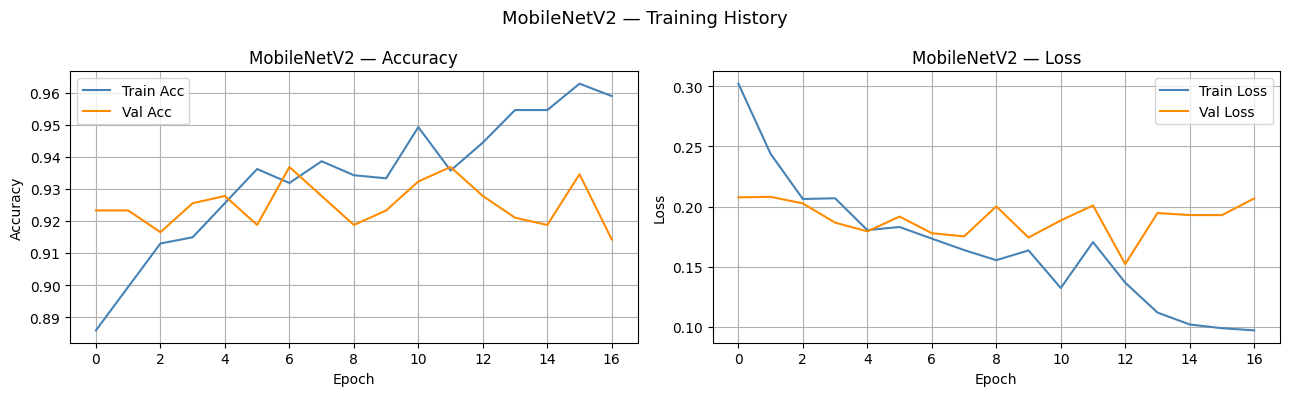

Saved: plots/mobilenetv2_training.png


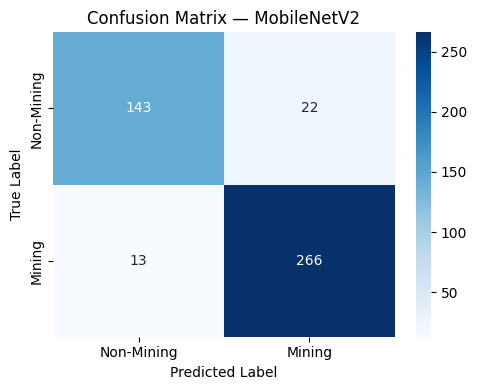

Saved: plots/mobilenetv2_cm.png


In [13]:
mobilenetv2.load_state_dict(torch.load('saved_models/mobilenetv2.pth',
                                          map_location=device))

mobilenet_results = evaluate_model(mobilenetv2, 'MobileNetV2', test_loader)

plot_history(history_m, 'MobileNetV2')
plot_confusion(mobilenet_results)


## Cell 14 — Load Custom CNN Results

Paste your Custom CNN test accuracy and AUC here so we can compare all three.


In [14]:
# ── Paste your Custom CNN numbers here ───────────────────────────────────
CUSTOM_CNN_TEST_ACC = 0.9167    # <-- update with your actual number
CUSTOM_CNN_AUC      = 0.9741    # <-- update with your actual AUC
#                                     (if you didn't compute AUC, set 0.0)

custom_cnn_results = {
    'name'    : 'Custom CNN',
    'accuracy': CUSTOM_CNN_TEST_ACC,
    'auc'     : CUSTOM_CNN_AUC,
}
print('Custom CNN results loaded.')
print(f'  Accuracy : {CUSTOM_CNN_TEST_ACC}')
print(f'  AUC-ROC  : {CUSTOM_CNN_AUC}')


Custom CNN results loaded.
  Accuracy : 0.9167
  AUC-ROC  : 0.9741


## Cell 15 — Model Comparison


  MODEL COMPARISON SUMMARY
  Model             Accuracy    AUC-ROC
  --------------------------------------
  Custom CNN          0.9167     0.9741
  ResNet-18           0.9189     0.9738
  MobileNetV2         0.9212     0.9734  <<< BEST


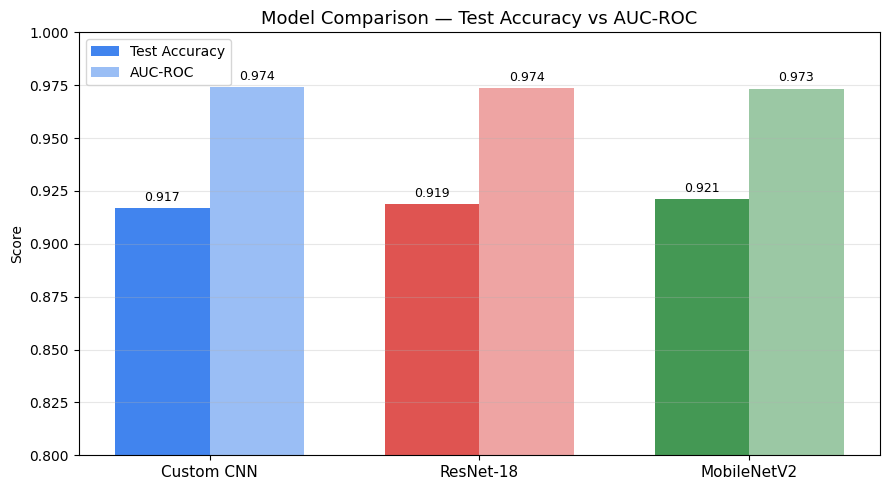

Saved: plots/model_comparison.png


In [15]:
all_results = [custom_cnn_results, resnet18_results, mobilenet_results]

# ── Summary table ─────────────────────────────────────────────────────────
print(f'\n{"="*55}')
print(f'  MODEL COMPARISON SUMMARY')
print(f'{"="*55}')
print(f'  {"Model":<15} {"Accuracy":>10} {"AUC-ROC":>10}')
print(f'  {"-"*38}')
for r in all_results:
    marker = '  <<< BEST' if r['accuracy'] == max(x['accuracy'] for x in all_results) else ''
    print(f'  {r["name"]:<15} {r["accuracy"]:>10.4f} {r["auc"]:>10.4f}{marker}')

# ── Bar chart ─────────────────────────────────────────────────────────────
names      = [r['name']     for r in all_results]
accuracies = [r['accuracy'] for r in all_results]
aucs       = [r['auc']      for r in all_results]
x          = np.arange(len(names))
width      = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width/2, accuracies, width, label='Test Accuracy',
            color=['#1F6FEB','#DA3633','#238636'], alpha=0.85)
b2 = ax.bar(x + width/2, aucs,       width, label='AUC-ROC',
            color=['#1F6FEB','#DA3633','#238636'], alpha=0.45)

ax.set_title('Model Comparison — Test Accuracy vs AUC-ROC', fontsize=13)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=11)
ax.set_ylim(0.80, 1.0); ax.set_ylabel('Score')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=9)

plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/model_comparison.png')


## Cell 16 — ROC Curves (All Models)

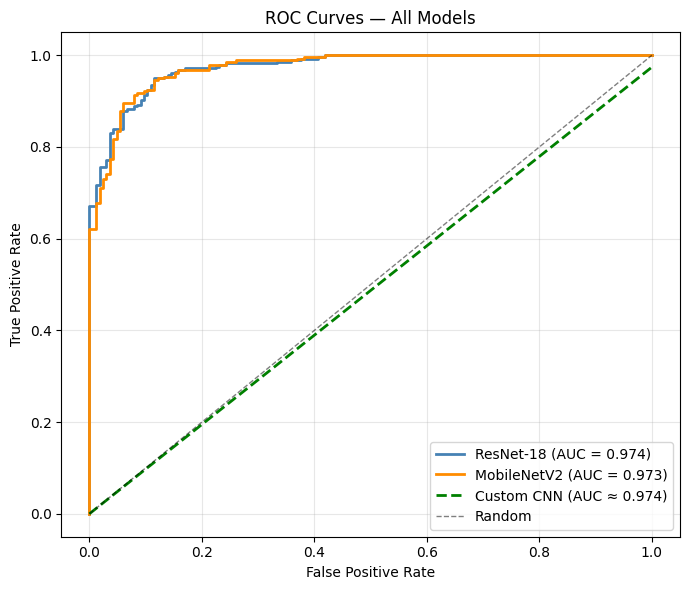

Saved: plots/roc_curves.png


In [16]:
fig, ax = plt.subplots(figsize=(7, 6))

for result, color in zip([resnet18_results, mobilenet_results],
                          ['steelblue', 'darkorange']):
    fpr, tpr, _ = roc_curve(result['labels'], result['probs'])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{result["name"]} (AUC = {result["auc"]:.3f})')

# Custom CNN line (approximate — straight line if you don't have probs)
ax.plot([0, 1], [0, CUSTOM_CNN_AUC], color='green', lw=2, linestyle='--',
        label=f'Custom CNN (AUC ≈ {CUSTOM_CNN_AUC:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/roc_curves.png')


## Cell 17 — Select & Save Best Model

In [17]:
# Automatically pick the model with highest test accuracy
best = max(all_results, key=lambda r: r['accuracy'])
print(f'Best model: {best["name"]}')
print(f'  Accuracy : {best["accuracy"]:.4f}')
print(f'  AUC-ROC  : {best["auc"]:.4f}')

# Copy best model checkpoint to best_model.pth
import shutil
src_map = {
    'Custom CNN' : 'saved_models/custom_cnn.pth',
    'ResNet-18'  : 'saved_models/resnet18.pth',
    'MobileNetV2': 'saved_models/mobilenetv2.pth',
}
src = src_map[best['name']]
shutil.copy(src, 'saved_models/best_model.pth')
print(f'\nCopied {src} -> saved_models/best_model.pth')
print('This is the model that will be used in inference_visualizer.ipynb')


Best model: MobileNetV2
  Accuracy : 0.9212
  AUC-ROC  : 0.9734

Copied saved_models/mobilenetv2.pth -> saved_models/best_model.pth
This is the model that will be used in inference_visualizer.ipynb


## Cell 18 — Summary

In [18]:
print('='*55)
print('  TRAINING COMPLETE')
print('='*55)
print()
print('Models saved in saved_models/:')
for f in sorted(os.listdir('saved_models')):
    size = os.path.getsize(f'saved_models/{f}') / 1024 / 1024
    print(f'  {f:<35} {size:.1f} MB')
print()
print('Plots saved in plots/:')
for f in sorted(os.listdir('plots')):
    print(f'  {f}')
print()
print('Next step -> build inference_visualizer.ipynb')
print('  That notebook will:')
print('  1. Load best_model.pth')
print('  2. Slide 64x64 window across a full Sentinel-2 scene')
print('  3. Overlay detected mining patches on the satellite image')
print('  4. Output GPS coordinates of detected mines')
print('  5. Export visual map + CSV report')


  TRAINING COMPLETE

Models saved in saved_models/:
  best_model.pth                      10.0 MB
  custom_cnn.pth                      4.4 MB
  mobilenetv2.pth                     10.0 MB
  mobilenetv2_phase1.pth              10.0 MB
  resnet18.pth                        43.2 MB
  resnet18_phase1.pth                 43.2 MB

Plots saved in plots/:
  custom_cnn_confusion_matrix.png
  custom_cnn_training.png
  mobilenetv2_cm.png
  mobilenetv2_training.png
  model_comparison.png
  resnet_18_cm.png
  resnet_18_training.png
  roc_curves.png

Next step -> build inference_visualizer.ipynb
  That notebook will:
  1. Load best_model.pth
  2. Slide 64x64 window across a full Sentinel-2 scene
  3. Overlay detected mining patches on the satellite image
  4. Output GPS coordinates of detected mines
  5. Export visual map + CSV report
